# **Counting Circles, Ellipses and Finding Waldo**

## **Objectives:**
1. Mini Project on Counting Circular Blobs
2. Mini Project on using Template Matching to find Waldo

> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 12):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

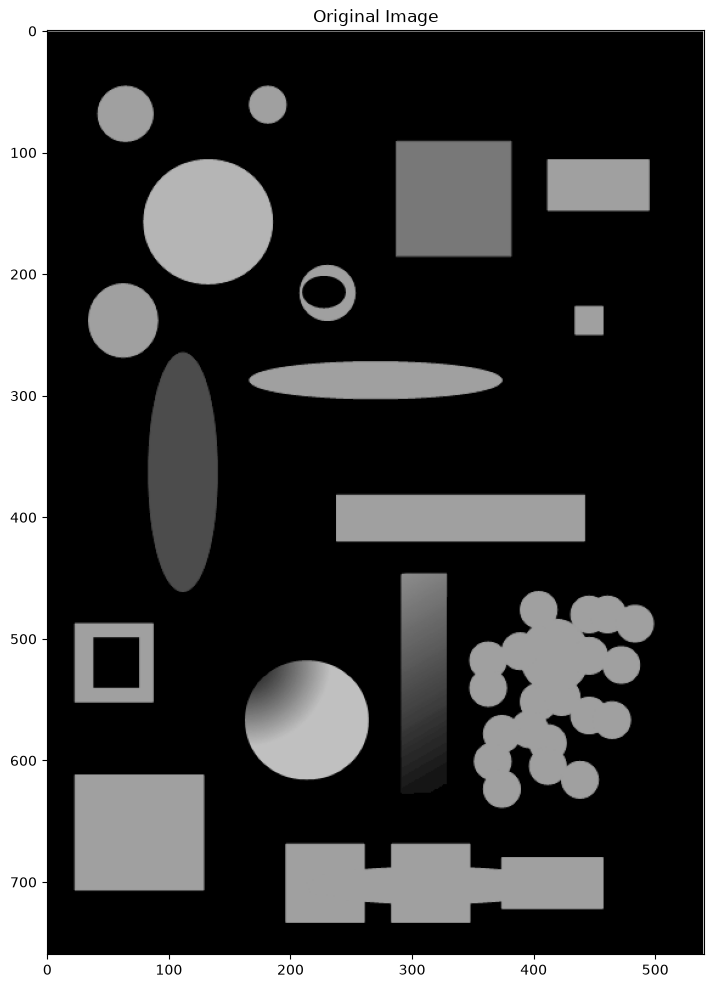

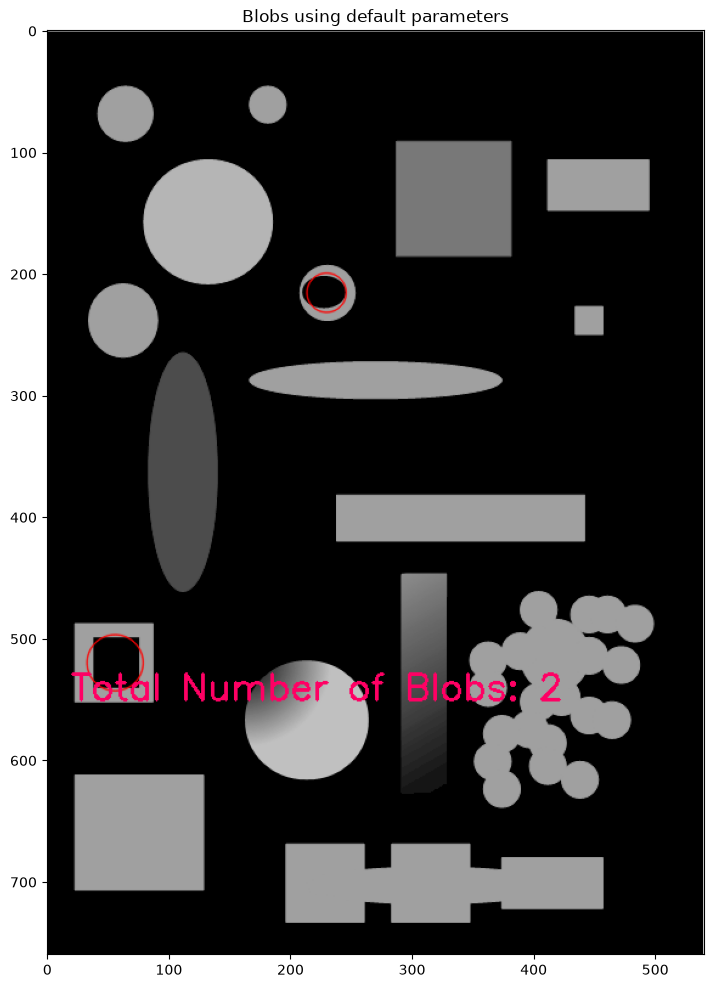

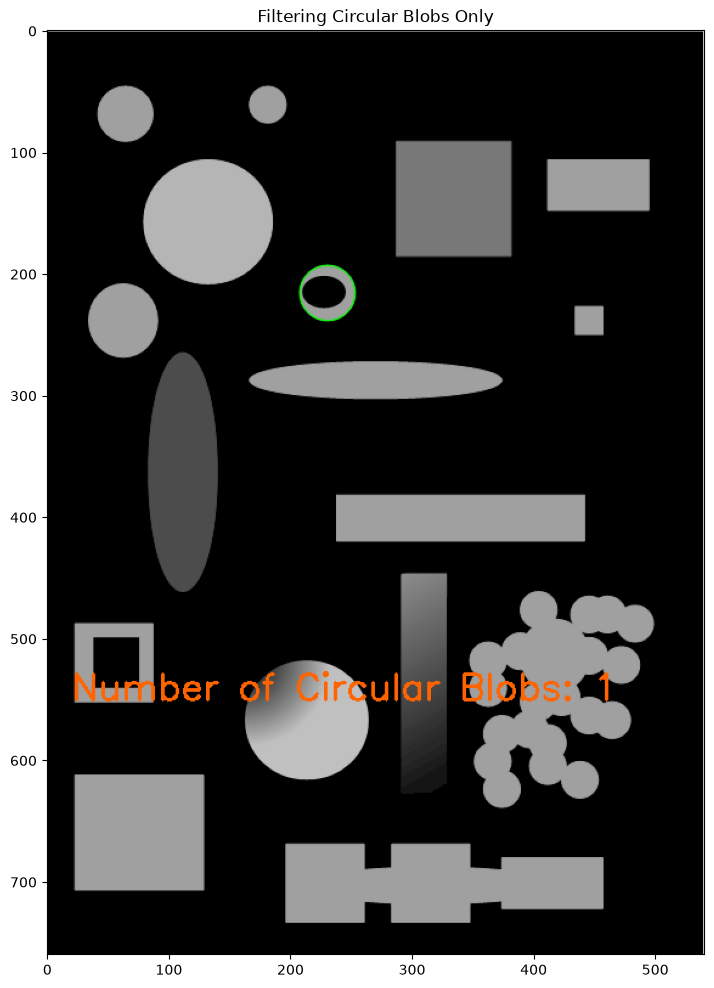

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load image
image = cv2.imread("assets/images/blobs.jpg", 0)
imshow('Original Image',image)

# Intialize the detector using the default parameters
detector = cv2.SimpleBlobDetector_create()
 
# Detect blobs
keypoints = detector.detect(image)
 
# Draw blobs on our image as red circles
blank = np.zeros((1,1)) 
blobs = cv2.drawKeypoints(image, keypoints, blank, (0,0,255),
                                      cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

number_of_blobs = len(keypoints)
text = "Total Number of Blobs: " + str(len(keypoints))
cv2.putText(blobs, text, (20, 550), cv2.FONT_HERSHEY_SIMPLEX, 1, (100, 0, 255), 2)

# Display image with blob keypoints
imshow("Blobs using default parameters", blobs)

# Set our filtering parameters
# Initialize parameter settiing using cv2.SimpleBlobDetector
params = cv2.SimpleBlobDetector_Params()

# Set Area filtering parameters
params.filterByArea = True
params.minArea = 100

# Set Circularity filtering parameters
params.filterByCircularity = True 
params.minCircularity = 0.9

# Set Convexity filtering parameters
params.filterByConvexity = False
params.minConvexity = 0.2
    
# Set inertia filtering parameters
params.filterByInertia = True
params.minInertiaRatio = 0.01

# Create a detector with the parameters
detector = cv2.SimpleBlobDetector_create(params)
    
# Detect blobs
keypoints = detector.detect(image)

# Draw blobs on our image as red circles
blank = np.zeros((1,1)) 
blobs = cv2.drawKeypoints(image, keypoints, blank, (0,255,0),
                                      cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

number_of_blobs = len(keypoints)
text = "Number of Circular Blobs: " + str(len(keypoints))
cv2.putText(blobs, text, (20, 550), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 100, 255), 2)

# Show blobs
imshow("Filtering Circular Blobs Only", blobs)


## Finding Waldo

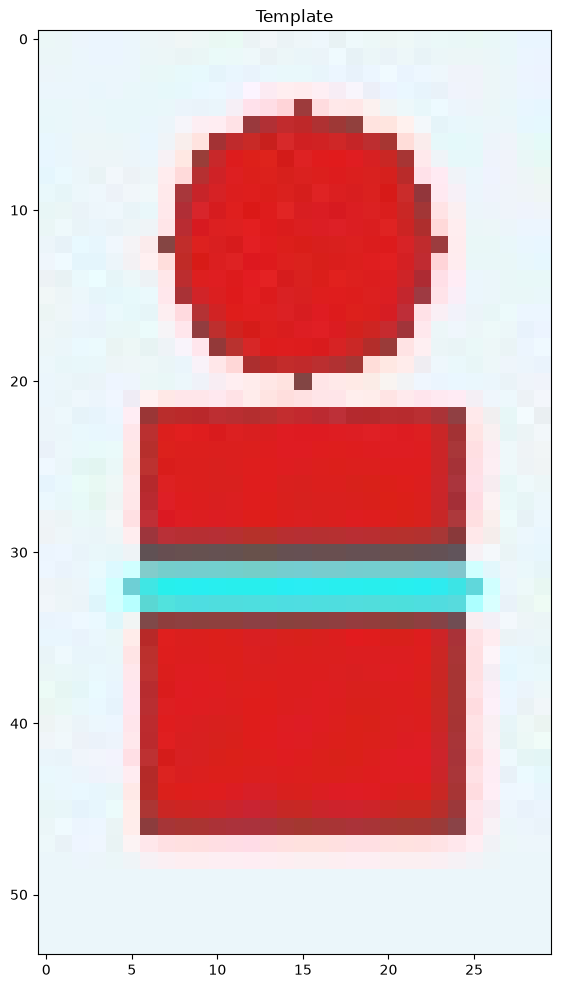

In [3]:
template = cv2.imread('./assets/images/waldo.jpg')
imshow('Template', template)

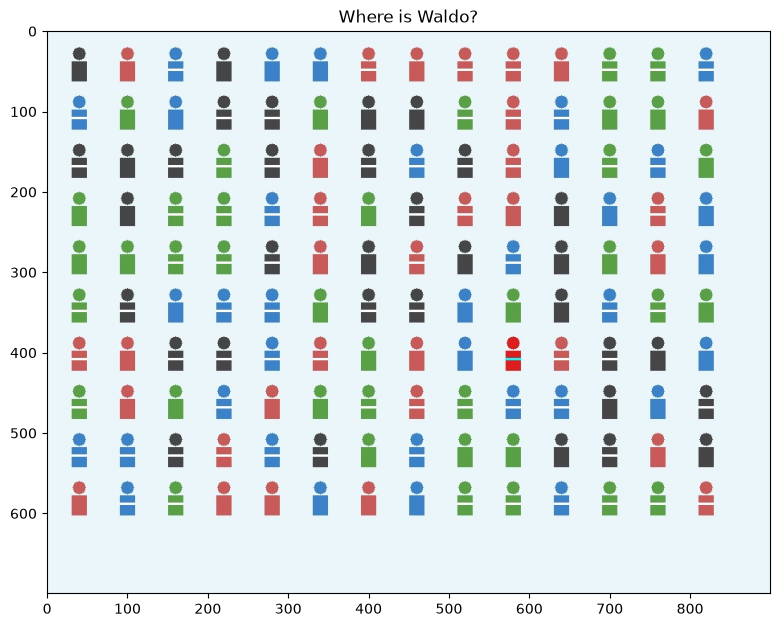

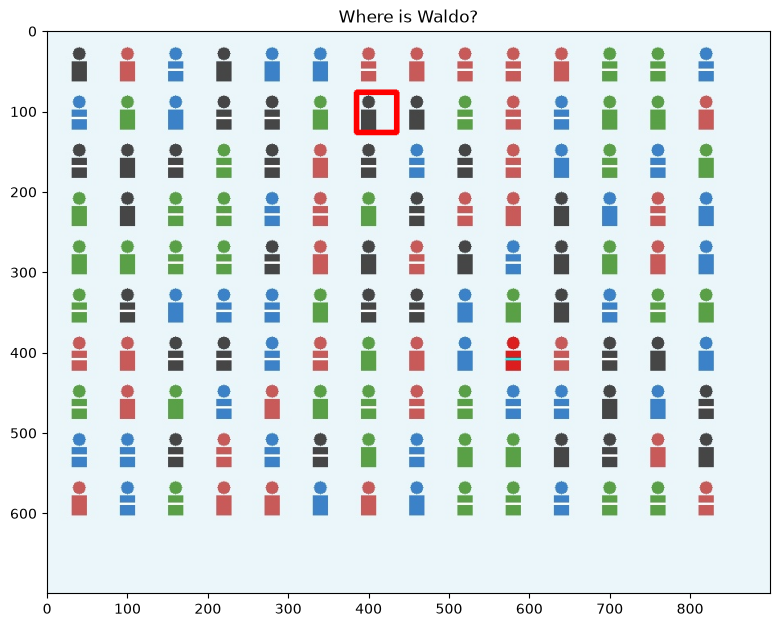

In [4]:
# Load input image and convert to grayscale
image = cv2.imread('./assets/images/WaldoBeach.jpg')
imshow('Where is Waldo?', image)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Load Template image
template = cv2.imread('./assets/images/waldo.jpg',0)

result = cv2.matchTemplate(gray, template, cv2.TM_CCOEFF)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

#Create Bounding Box
top_left = max_loc
bottom_right = (top_left[0] + 50, top_left[1] + 50)
cv2.rectangle(image, top_left, bottom_right, (0,0,255), 5)

imshow('Where is Waldo?', image)

### If you want to push this further

- The find-the-target scene here is a small, from-scratch template-matching demo (not the original book's Where's Waldo art, which isn't ours to redistribute) — see the README for why. Try `cv2.TM_CCOEFF_NORMED` instead of `TM_CCOEFF` and threshold `max_val` directly to decide *whether* the target is present at all, not just where.
- Blob-count sensitivity: sweep `params.minArea` from 50 to 500 on `images/blobs.jpg` and plot the resulting blob count — there's a knee where noise stops being filtered.